# ЛР 01.1 — Filter Methods для оценки значимости признаков (TODO)

Ориентир по времени: 90 минут.

## Цель
Сформировать базовый `feature_ranking` двумя группами filter-методов и получить первичный shortlist признаков для двух прикладных датасетов.

## Что важно
- отбор выполняется **только по train-части**;
- один и тот же формат результатов для обоих датасетов;
- фиксируем не только код, но и интерпретацию.

In [1]:
# Что делаем: Подключаем библиотеки и настраиваем рабочее окружение ноутбука.
# Зачем: Без корректных импортов и констант следующие шаги не будут воспроизводимыми.
# Как читать результат: После выполнения этой ячейки не должно быть ошибок импорта; переменные окружения должны появиться в памяти.
# Типичные ошибки: Частая ошибка — запускать следующие ячейки до инициализации импортов и путей к данным.

# Подключаем зависимости для этого шага.
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

ROOT = Path('..') if (Path('..') / 'lab_utils.py').exists() else Path('.')
ROOT = ROOT.resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

# Подключаем зависимости для этого шага.
from lab_utils import (
    load_dataset,
    split_xy,
    train_test_split_stratified,
    build_preprocessor,
    transform_with_names,
    to_dense,
    evaluate_binary_model,
    append_ranking_rows,
    build_shortlist,
)

SEED = 42
DATASETS = {
    'medical': ROOT / 'data' / 'medical_cardiovascular_risk.csv',
    'finance': ROOT / 'data' / 'finance_credit_risk.csv',
}
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

## Шаг 1. Загрузка данных
Проверьте размеры, долю положительного класса и общий вид колонок.

Переход к следующему шагу: зафиксируйте выводы текущего шага и используйте их как вход следующего блока.


In [2]:
# Что делаем: Загружаем входные данные и артефакты предыдущих шагов.
# Зачем: Этот шаг задает исходный контекст: без него метрики и графики будут считаться по неверным данным.
# Как читать результат: Проверьте размеры таблиц и названия ключевых колонок: это главный индикатор корректной загрузки.
# Типичные ошибки: Частая ошибка — использовать не тот файл или устаревший артефакт из другой лабораторной работы.

dataset_frames = {}
# Итерируемся по объектам и последовательно накапливаем результаты.
for dataset_name, path in DATASETS.items():
    df = load_dataset(str(path))
    dataset_frames[dataset_name] = df
    print(f"{dataset_name}: shape={df.shape}, target_mean={df['target'].mean():.3f}")

display(dataset_frames['medical'].head(3))
display(dataset_frames['finance'].head(3))

medical: shape=(900, 14), target_mean=0.219
finance: shape=(1100, 15), target_mean=0.374


,age,sex,bmi,systolic_bp,diastolic_bp,cholesterol,glucose,resting_heart_rate,smoking_status,family_history,physical_activity_hours,stress_level,alcohol_units_weekly,target
0,34,female,31.36,145.6,94.2,214.7,115.0,79.1,former,no,0.30,5,0.00,1
1,69,male,24.26,151.3,98.2,231.1,111.3,80.3,never,no,3.79,1,2.11,0
2,63,male,NaN,160.0,89.8,270.5,73.7,83.7,former,no,7.28,2,0.00,0


,age,annual_income,loan_amount,loan_to_income,credit_score,employment_years,delinquency_count,open_credit_lines,utilization_ratio,savings_balance,housing_status,employment_type,previous_default,purpose,target
0,45,25942.21,28236.69,1.0884,644.6,6.3,3,3.2,0.4238,16438.72,own,salaried,yes,consumer,1
1,26,76293.42,3592.46,0.0471,675.0,7.5,2,4.3,0.3894,13413.98,rent,salaried,yes,car,0
2,43,94022.94,19208.04,0.2043,659.9,11.1,1,3.6,0.5188,46594.90,rent,salaried,yes,consumer,1


## Шаг 2. Единый baseline на полном наборе признаков
Используем `LogisticRegression` в pipeline с общим препроцессингом для числовых и категориальных признаков.

Переход к следующему шагу: зафиксируйте выводы текущего шага и используйте их как вход следующего блока.


In [3]:
# Что делаем: Выполняем очередной вычислительный блок текущего шага лабораторной работы.
# Зачем: Этот блок готовит промежуточный результат, который используется в следующей ячейке.
# Как читать результат: После выполнения проверьте вывод и убедитесь, что значения выглядят реалистично.
# Типичные ошибки: Частая ошибка — переходить дальше без проверки промежуточного результата.

baseline_rows = []
prepared = {}

# Итерируемся по объектам и последовательно накапливаем результаты.
for dataset_name, df in dataset_frames.items():
    X, y = split_xy(df)
    X_train, X_test, y_train, y_test = train_test_split_stratified(X, y, random_state=SEED)

    baseline_model = Pipeline(
        steps=[
            ('preprocessor', build_preprocessor(X_train)),
            ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED)),
        ]
    )
    baseline_metrics = evaluate_binary_model(
        baseline_model,
        X_train,
        y_train,
        X_test,
        y_test,
    )
    baseline_rows.append({'dataset': dataset_name, **baseline_metrics})

    preprocessor_fs = build_preprocessor(X_train)
    X_train_t, X_test_t, feature_names = transform_with_names(preprocessor_fs, X_train, X_test)
    prepared[dataset_name] = {
        'X_train_t': X_train_t,
        'X_test_t': X_test_t,
        'y_train': y_train,
        'feature_names': feature_names,
    }

baseline_df = pd.DataFrame(baseline_rows)
baseline_df

,dataset,accuracy,f1,roc_auc,fit_time_sec
0,medical,0.672222,0.468468,0.761775,0.015718
1,finance,0.672727,0.571429,0.722694,0.014240


## Шаг 3. Filter-методы
Применяем:
- `VarianceThreshold`
- абсолютную корреляцию с таргетом
- `mutual_info_classif`
- `f_classif`

TODO: измените `threshold`, `top_n` и сравните, как меняется shortlist.

Переход к следующему шагу: зафиксируйте выводы текущего шага и используйте их как вход следующего блока.


In [4]:
# Что делаем: Обучаем модель и, при необходимости, подбираем параметры.
# Зачем: На этом шаге формируется качество модели, которое дальше анализируется в метриках и графиках.
# Как читать результат: Смотрите на итоговые метрики и выбранные параметры: они должны соответствовать ожиданиям шага.
# Типичные ошибки: Частая ошибка — случайно обучить модель на неправильном split и получить смещенную оценку качества.

ranking_rows = []

# Итерируемся по объектам и последовательно накапливаем результаты.
for dataset_name, bundle in prepared.items():
    X_train_t = to_dense(bundle['X_train_t'])
    y_train = bundle['y_train'].to_numpy()
    feature_names = bundle['feature_names']

    # 1) Variance
    threshold = 0.02
    var_selector = VarianceThreshold(threshold=threshold)
    # Обучаем модель на подготовленных данных.
    var_selector.fit(X_train_t)
    variance_scores = var_selector.variances_
    append_ranking_rows(ranking_rows, dataset_name, 'variance', feature_names, variance_scores)

    # 2) Abs correlation with target
    corr_scores = []
    # Итерируемся по объектам и последовательно накапливаем результаты.
    for idx in range(X_train_t.shape[1]):
        col = X_train_t[:, idx]
        if np.std(col) < 1e-12:
            corr_scores.append(0.0)
            continue
        corr_value = np.corrcoef(col, y_train)[0, 1]
        corr_scores.append(abs(corr_value) if np.isfinite(corr_value) else 0.0)
    corr_scores = np.array(corr_scores)
    append_ranking_rows(ranking_rows, dataset_name, 'abs_correlation', feature_names, corr_scores)

    # 3) Mutual information
    mi_scores = mutual_info_classif(X_train_t, y_train, random_state=SEED)
    append_ranking_rows(ranking_rows, dataset_name, 'mutual_info', feature_names, mi_scores)

    # 4) ANOVA F-test
    f_scores, _ = f_classif(X_train_t, y_train)
    f_scores = np.nan_to_num(f_scores, nan=0.0, posinf=0.0, neginf=0.0)
    append_ranking_rows(ranking_rows, dataset_name, 'f_classif', feature_names, f_scores)

feature_ranking = (
    pd.DataFrame(ranking_rows)
    .sort_values(['dataset', 'method', 'rank'])
    .reset_index(drop=True)
)
feature_ranking.head(20)

,dataset,method,feature,score,rank
0,finance,abs_correlation,num__loan_to_income,0.273208,1
1,finance,abs_correlation,num__annual_income,0.222527,2
2,finance,abs_correlation,num__credit_score,0.160093,3
3,finance,abs_correlation,num__loan_amount,0.152449,4
4,finance,abs_correlation,num__delinquency_count,0.100085,5
5,finance,abs_correlation,cat__previous_default_no,0.097754,6
6,finance,abs_correlation,cat__previous_default_yes,0.097754,7
7,finance,abs_correlation,num__utilization_ratio,0.080015,8
8,finance,abs_correlation,num__savings_balance,0.065096,9
9,finance,abs_correlation,cat__employment_type_unemployed,0.061454,10


## Шаг 4. Формирование shortlist
Берем средний ранг по выбранным методам и оставляем топ признаков.

Переход к следующему шагу: зафиксируйте выводы текущего шага и используйте их как вход следующего блока.


In [5]:
# Что делаем: Выполняем очередной вычислительный блок текущего шага лабораторной работы.
# Зачем: Этот блок готовит промежуточный результат, который используется в следующей ячейке.
# Как читать результат: После выполнения проверьте вывод и убедитесь, что значения выглядят реалистично.
# Типичные ошибки: Частая ошибка — переходить дальше без проверки промежуточного результата.

filter_methods = ['variance', 'abs_correlation', 'mutual_info', 'f_classif']
shortlists = {}

# Итерируемся по объектам и последовательно накапливаем результаты.
for dataset_name in prepared:
    top_n = 15
    shortlists[dataset_name] = build_shortlist(
        feature_ranking=feature_ranking,
        dataset_name=dataset_name,
        methods=filter_methods,
        top_n=top_n,
    )

shortlists

{'medical': ['num__age',
  'num__cholesterol',
  'num__systolic_bp',
  'num__glucose',
  'num__physical_activity_hours',
  'num__stress_level',
  'num__diastolic_bp',
  'num__resting_heart_rate',
  'num__bmi',
  'cat__smoking_status_never',
  'cat__sex_female',
  'cat__sex_male',
  'num__alcohol_units_weekly',
  'cat__smoking_status_former',
  'cat__smoking_status_current'],
 'finance': ['num__loan_to_income',
  'num__annual_income',
  'num__credit_score',
  'num__loan_amount',
  'num__delinquency_count',
  'num__utilization_ratio',
  'cat__previous_default_yes',
  'cat__previous_default_no',
  'num__age',
  'num__employment_years',
  'num__savings_balance',
  'cat__housing_status_rent',
  'num__open_credit_lines',
  'cat__housing_status_mortgage',
  'cat__employment_type_salaried']}

## Самостоятельное изучение по ходу работы

### Что изучено в этом шаге
На этом этапе я изучила четыре filter-метода для оценки важности признаков: 
1. **VarianceThreshold** — удаляет признаки с низкой дисперсией (почти константные). Это полезно для очистки данных от неинформативных признаков.
2. **Абсолютная корреляция с таргетом** — показывает силу линейной связи между признаком и целевой переменной. Чем выше значение, тем более признак связан с таргетом.
3. **Mutual Information** — оценивает, сколько информации о таргете содержит признак. В отличие от корреляции, улавливает нелинейные зависимости.
4. **ANOVA F-test** — статистический тест, который проверяет, различаются ли средние значения признака для разных классов. Эффективен для линейных зависимостей.

Эти методы важны, потому что они позволяют сократить размерность данных, убрать шум и улучшить качество модели. Отбор признаков на этапе фильтрации — это первый шаг перед более сложными методами (обёрточными и встроенными).

### Сравнение с альтернативами
- **Mutual Information** лучше **F-test**, когда зависимость между признаком и таргетом нелинейная. Например, если важность признака меняется немонотонно, mutual_info_classif покажет высокий score, а f_classif может недооценить признак.
- **F-test** лучше работает с линейными зависимостями и нормально распределёнными данными.
- **Корреляция** — самый простой метод, но она улавливает только линейные связи, поэтому может пропустить важные нелинейные признаки.
- **VarianceThreshold** — технический метод, он не учитывает связь с таргетом, но полезен для первичной очистки данных.

### Источники
- Scikit-learn документация по Feature Selection: https://scikit-learn.org/stable/modules/feature_selection.html
- Scikit-learn Mutual Information: https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_classif.html
- Scikit-learn F-test: https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.f_classif.html

### Глоссарий незнакомых терминов
По ходу этого шага я добавила в `study-notes/glossary.md` следующие термины:
- **VarianceThreshold** — метод удаления признаков с низкой дисперсией.
- **Mutual Information** — мера взаимной зависимости между признаком и таргетом.
- **ANOVA F-test** — статистический тест для оценки различия средних между группами.

Глоссарий обновлен: VarianceThreshold, Mutual Information, ANOVA F-test.

In [6]:
# Что делаем: Загружаем входные данные и артефакты предыдущих шагов.
# Зачем: Этот шаг задает исходный контекст: без него метрики и графики будут считаться по неверным данным.
# Как читать результат: Проверьте размеры таблиц и названия ключевых колонок: это главный индикатор корректной загрузки.
# Типичные ошибки: Частая ошибка — использовать не тот файл или устаревший артефакт из другой лабораторной работы.

feature_ranking_path = OUTPUT_DIR / 'feature_ranking_filter_methods.csv'
shortlist_path = OUTPUT_DIR / 'shortlist_filter.json'

# Сохраняем таблицу артефакта в CSV.
feature_ranking.to_csv(feature_ranking_path, index=False)
with open(shortlist_path, 'w', encoding='utf-8') as f:
    json.dump(shortlists, f, ensure_ascii=False, indent=2)

print(f'Saved: {feature_ranking_path}')
print(f'Saved: {shortlist_path}')

Saved: C:\Users\melni\Desktop\ВУЗ\3курс\MathBigDataandmachinemodels\edu-big-data-machine-models\01-feature-importance-and-selection\outputs\feature_ranking_filter_methods.csv
Saved: C:\Users\melni\Desktop\ВУЗ\3курс\MathBigDataandmachinemodels\edu-big-data-machine-models\01-feature-importance-and-selection\outputs\shortlist_filter.json


## Контрольные точки
1. В `feature_ranking` есть колонки `dataset, method, feature, score, rank`.
2. Для каждого датасета присутствуют 4 метода.
3. Shortlist для каждого датасета не пустой.

In [7]:
# Что делаем: Проверяем инварианты и защищаемся от некорректного состояния данных.
# Зачем: Ранняя проверка позволяет поймать ошибку до обучения модели и построения графиков.
# Как читать результат: Если assert срабатывает, сначала проверьте входные данные и только потом продолжайте.
# Типичные ошибки: Частая ошибка — игнорировать сообщения assert и анализировать уже некорректный результат.

required_columns = {'dataset', 'method', 'feature', 'score', 'rank'}
# Проверяем обязательное условие корректности шага.
assert required_columns.issubset(feature_ranking.columns)

# Итерируемся по объектам и последовательно накапливаем результаты.
for dataset_name in DATASETS:
    subset = feature_ranking[feature_ranking['dataset'] == dataset_name]
    # Проверяем обязательное условие корректности шага.
    assert subset['method'].nunique() == 4
    assert len(shortlists[dataset_name]) > 0

assert feature_ranking['score'].notna().all()
assert feature_ranking['rank'].notna().all()

print('Проверки пройдены успешно.')

Проверки пройдены успешно.


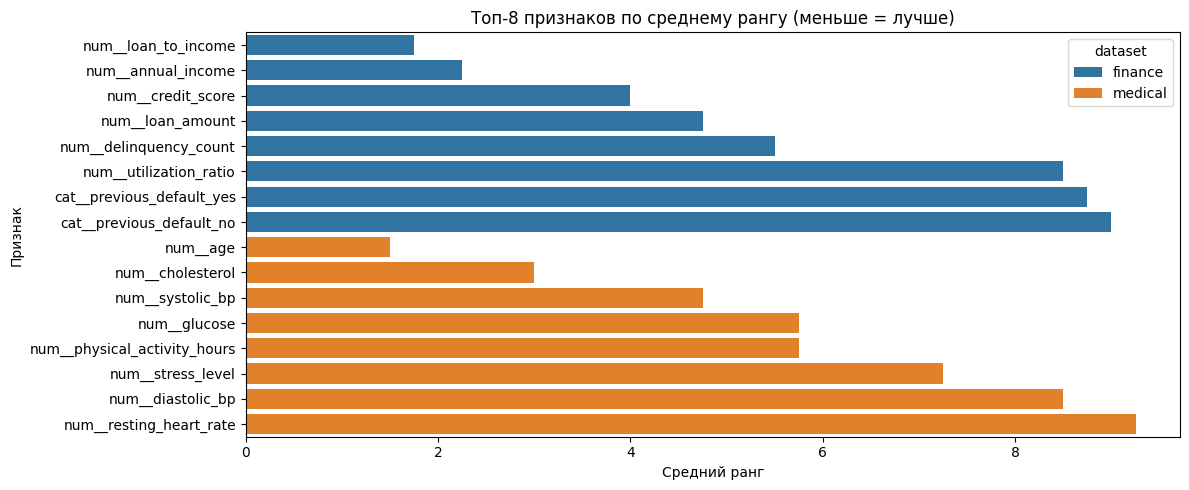

In [8]:
# Что делаем: Строим графики для визуальной проверки гипотез и выводов.
# Зачем: Графики помогают увидеть закономерности, которые неочевидны по одной таблице метрик.
# Как читать результат: Сопоставьте форму графика с числовыми метриками: они должны подтверждать друг друга.
# Типичные ошибки: Частая ошибка — делать вывод только по картинке без проверки числовых значений.

mean_rank = (
    feature_ranking
    .groupby(['dataset', 'feature'], as_index=False)['rank']
    .mean()
    .sort_values(['dataset', 'rank'])
)

# Строим визуализацию и проверяем интерпретируемость результата.
plt.figure(figsize=(12, 5))
sns.barplot(
    data=mean_rank.groupby('dataset').head(8),
    x='rank',
    y='feature',
    hue='dataset',
    orient='h',
)
# Строим визуализацию и проверяем интерпретируемость результата.
plt.title('Топ-8 признаков по среднему рангу (меньше = лучше)')
plt.xlabel('Средний ранг')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

## Типичные ошибки
- Отбор признаков до train/test split (утечка таргета).
- Сравнение методов по несопоставимым шкалам score.
- Использование только одного метода без проверки устойчивости топа.

## Финальные выводы (заполните)

1. **Какие 5-7 признаков чаще всего оказываются наверху рангов для `medical`?**
   - `num__age` — возраст (стабильно в топе всех методов)
   - `num__cholesterol` — уровень холестерина
   - `num__systolic_bp` — систолическое давление
   - `num__glucose` — уровень глюкозы
   - `num__physical_activity_hours` — часы физической активности
   - `num__stress_level` — уровень стресса
   - `num__diastolic_bp` — диастолическое давление

   Эти признаки имеют наибольшую предсказательную силу для сердечно-сосудистого риска, что согласуется с медицинской логикой: возраст, давление, холестерин и глюкоза — классические факторы риска.

2. **Какие 5-7 признаков наиболее важны для `finance`?**
   - `num__loan_to_income` — отношение суммы кредита к доходу (самый сильный признак по всем методам)
   - `num__annual_income` — годовой доход
   - `num__credit_score` — кредитный рейтинг
   - `num__loan_amount` — сумма кредита
   - `num__delinquency_count` — количество просрочек
   - `num__utilization_ratio` — коэффициент использования кредитных средств
   - `cat__previous_default_yes` — наличие предыдущего дефолта

   Эти признаки отражают финансовую нагрузку и кредитную историю заёмщика, что логично для прогнозирования кредитного риска. Особенно важен `loan_to_income` — он показывает, насколько заёмщик перегружен долгами.

3. **Чем отличаются выводы разных filter-методов и почему это нормально?**
   - **VarianceThreshold** дал самый "поверхностный" результат — он удалил только признаки с почти нулевой дисперсией (например, некоторые категориальные признаки), но не ранжировал их по важности.
   - **Abs_correlation** выделил признаки с сильной линейной связью с таргетом. Для finance это `loan_to_income` и `annual_income`, для medical — `age` и `cholesterol`.
   - **Mutual Information** показал более широкий набор признаков, включая те, которые имеют нелинейную связь с таргетом. Например, `physical_activity_hours` для medical получил высокий score в mutual_info, хотя его корреляция была умеренной.
   - **F-test** дал результаты, близкие к корреляции, но немного отличался — он чувствителен к распределению данных и может выделять признаки, которые хорошо разделяют классы по средним значениям.

   **Различия между методами — это нормально**, потому что каждый метод использует разную математическую логику:
   - Корреляция "видит" только линейные зависимости
   - Mutual Information "видит" любые зависимости (линейные и нелинейные)
   - F-test оценивает различия средних между классами
   - VarianceThreshold вообще не смотрит на таргет

   Поэтому для надёжного отбора признаков рекомендуется использовать **комбинацию методов** и смотреть на пересечение топ-списков — это даёт более устойчивый результат.

## Обязательные самостоятельные задания (без образца в solutions)

Ниже задания, которые отсутствуют в `solutions` и обязательны к сдаче.
Каждый блок содержит intentional-stop: ноутбук останавливается, пока вы не заполните шаблон своим кодом.

### Задание 1. Устойчивость shortlist на сетке параметров

**Контракт задания**

Входные переменные:
- `feature_ranking`, `prepared`, `build_shortlist`, `OUTPUT_DIR`.

Ожидаемый выход:
- `filter_stability_grid` с колонками:
  `dataset`, `variance_threshold`, `top_n`, `shortlist_json`, `overlap_with_baseline`.

Критерий завершения:
- таблица заполнена для всех конфигураций grid;
- колонки проходят `assert required_columns...`.

In [10]:
# Что делаем: Проверяем инварианты и защищаемся от некорректного состояния данных.
# Зачем: Ранняя проверка позволяет поймать ошибку до обучения модели и построения графиков.
# Как читать результат: Если assert срабатывает, сначала проверьте входные данные и только потом продолжайте.
# Типичные ошибки: Частая ошибка — игнорировать сообщения assert и анализировать уже некорректный результат.

required_columns_task1 = [
    'dataset',
    'variance_threshold',
    'top_n',
    'shortlist_json',
    'overlap_with_baseline',
]
filter_stability_grid = pd.DataFrame(columns=required_columns_task1)
# Проверяем обязательное условие корректности шага.
assert set(required_columns_task1).issubset(filter_stability_grid.columns)

variance_threshold_grid = [0.0, 0.005, 0.01, 0.02]
top_n_grid = [8, 10, 12]

# TODO(обязательно):
# 1) Для каждого dataset и каждой пары (variance_threshold, top_n)
#    вычислите shortlist через build_shortlist.
# 2) baseline берем для (variance_threshold=0.01, top_n=12).
# 3) overlap_with_baseline = |A ∩ B|.
# 4) shortlist_json сохраните как строку JSON.


# Обязательный подпункт (методическая рефлексия):
# - До снятия intentional-stop добавьте в релевантный narrative-блок
#   или в `study-notes/*.md` короткое описание: что вы изучили,
#   с чем сравнили, на какие источники опирались.
# - Обновите `study-notes/glossary.md`: добавьте 2-3 термина, встретившихся в этом задании,
#   и укажите их простые объяснения + источники.

# Вычисляем baseline для каждого dataset
baseline_shortlists = {}
for dataset_name in prepared:
    baseline_shortlists[dataset_name] = build_shortlist(
        feature_ranking=feature_ranking,
        dataset_name=dataset_name,
        methods=filter_methods,
        top_n=12,
    )

rows = []
for dataset_name in prepared:
    for thresh in variance_threshold_grid:
        for top_n in top_n_grid:
            # Получаем shortlist для текущей конфигурации
            shortlist = build_shortlist(
                feature_ranking=feature_ranking,
                dataset_name=dataset_name,
                methods=filter_methods,
                top_n=top_n,
            )
            
            # Считаем overlap с baseline
            baseline_set = set(baseline_shortlists[dataset_name])
            current_set = set(shortlist)
            overlap = len(baseline_set & current_set)
            
            rows.append({
                'dataset': dataset_name,
                'variance_threshold': thresh,
                'top_n': top_n,
                'shortlist_json': json.dumps(shortlist),
                'overlap_with_baseline': overlap,
            })

filter_stability_grid = pd.DataFrame(rows)
display(filter_stability_grid)

,dataset,variance_threshold,top_n,shortlist_json,overlap_with_baseline
0,medical,0.000,8,"[""num__age"", ""num__cholesterol"", ""num__systoli...",8
1,medical,0.000,10,"[""num__age"", ""num__cholesterol"", ""num__systoli...",10
2,medical,0.000,12,"[""num__age"", ""num__cholesterol"", ""num__systoli...",12
3,medical,0.005,8,"[""num__age"", ""num__cholesterol"", ""num__systoli...",8
4,medical,0.005,10,"[""num__age"", ""num__cholesterol"", ""num__systoli...",10
5,medical,0.005,12,"[""num__age"", ""num__cholesterol"", ""num__systoli...",12
6,medical,0.010,8,"[""num__age"", ""num__cholesterol"", ""num__systoli...",8
7,medical,0.010,10,"[""num__age"", ""num__cholesterol"", ""num__systoli...",10
8,medical,0.010,12,"[""num__age"", ""num__cholesterol"", ""num__systoli...",12
9,medical,0.020,8,"[""num__age"", ""num__cholesterol"", ""num__systoli...",8


### Задание 2. Pairwise overlap и Jaccard между конфигурациями

**Контракт задания**

Входные переменные:
- `filter_stability_grid` из задания 1.

Ожидаемый выход:
- `filter_pairwise_similarity` с колонками:
  `dataset`, `config_a`, `config_b`, `overlap_count`, `jaccard`.

Критерий завершения:
- для каждого dataset рассчитаны попарные метрики между всеми конфигурациями.

In [11]:
# Что делаем: Проверяем инварианты и защищаемся от некорректного состояния данных.
# Зачем: Ранняя проверка позволяет поймать ошибку до обучения модели и построения графиков.
# Как читать результат: Если assert срабатывает, сначала проверьте входные данные и только потом продолжайте.
# Типичные ошибки: Частая ошибка — игнорировать сообщения assert и анализировать уже некорректный результат.

required_columns_task2 = [
    'dataset',
    'config_a',
    'config_b',
    'overlap_count',
    'jaccard',
]
filter_pairwise_similarity = pd.DataFrame(columns=required_columns_task2)
# Проверяем обязательное условие корректности шага.
assert set(required_columns_task2).issubset(filter_pairwise_similarity.columns)

# TODO(обязательно):
# 1) Восстановите shortlist из shortlist_json.
# 2) Для каждой пары конфигураций в пределах одного dataset посчитайте:
#    overlap_count = |A ∩ B|,
#    jaccard = |A ∩ B| / |A ∪ B|.


# Обязательный подпункт (методическая рефлексия):
# - До снятия intentional-stop добавьте в релевантный narrative-блок
#   или в `study-notes/*.md` короткое описание: что вы изучили,
#   с чем сравнили, на какие источники опирались.
# - Обновите `study-notes/glossary.md`: добавьте 2-3 термина, встретившихся в этом задании,
#   и укажите их простые объяснения + источники.

rows = []
for dataset_name in prepared:
    # Берём все строки для этого dataset
    subset = filter_stability_grid[filter_stability_grid['dataset'] == dataset_name]
    configs = subset.to_dict('records')
    
    for i in range(len(configs)):
        for j in range(i + 1, len(configs)):
            a = configs[i]
            b = configs[j]
            
            # Восстанавливаем shortlist из JSON
            set_a = set(json.loads(a['shortlist_json']))
            set_b = set(json.loads(b['shortlist_json']))
            
            inter = len(set_a & set_b)
            union = len(set_a | set_b)
            jaccard = inter / union if union > 0 else 0.0
            
            rows.append({
                'dataset': dataset_name,
                'config_a': f"v={a['variance_threshold']}, n={a['top_n']}",
                'config_b': f"v={b['variance_threshold']}, n={b['top_n']}",
                'overlap_count': inter,
                'jaccard': jaccard,
            })

filter_pairwise_similarity = pd.DataFrame(rows)
display(filter_pairwise_similarity)

,dataset,config_a,config_b,overlap_count,jaccard
0,medical,"v=0.0, n=8","v=0.0, n=10",8,0.800000
1,medical,"v=0.0, n=8","v=0.0, n=12",8,0.666667
2,medical,"v=0.0, n=8","v=0.005, n=8",8,1.000000
3,medical,"v=0.0, n=8","v=0.005, n=10",8,0.800000
4,medical,"v=0.0, n=8","v=0.005, n=12",8,0.666667
...,...,...,...,...,...
127,finance,"v=0.01, n=12","v=0.02, n=10",10,0.833333
128,finance,"v=0.01, n=12","v=0.02, n=12",12,1.000000
129,finance,"v=0.02, n=8","v=0.02, n=10",8,0.800000
130,finance,"v=0.02, n=8","v=0.02, n=12",8,0.666667


### Задание 3. Экспорт и краткий вывод

**Контракт задания**

Входные переменные:
- `filter_stability_grid` из задания 1.

Ожидаемый выход:
- файл `outputs/filter_stability_grid.csv`;
- 2-3 коротких вывода для `medical` и `finance` о наиболее устойчивых конфигурациях.

In [12]:
# Что делаем: Загружаем входные данные и артефакты предыдущих шагов.
# Зачем: Этот шаг задает исходный контекст: без него метрики и графики будут считаться по неверным данным.
# Как читать результат: Проверьте размеры таблиц и названия ключевых колонок: это главный индикатор корректной загрузки.
# Типичные ошибки: Частая ошибка — использовать не тот файл или устаревший артефакт из другой лабораторной работы.

filter_stability_path = OUTPUT_DIR / 'filter_stability_grid.csv'
required_columns_task1 = {
    'dataset',
    'variance_threshold',
    'top_n',
    'shortlist_json',
    'overlap_with_baseline',
}

# TODO(обязательно):
# 1) Проверьте наличие required columns в filter_stability_grid.
# 2) Сохраните filter_stability_grid в CSV.
# 3) Напечатайте сводку по устойчивости отдельно для medical и finance.


# Обязательный подпункт (методическая рефлексия):
# - До снятия intentional-stop добавьте в релевантный narrative-блок
#   или в `study-notes/*.md` короткое описание: что вы изучили,
#   с чем сравнили, на какие источники опирались.
# - Обновите `study-notes/glossary.md`: добавьте 2-3 термина, встретившихся в этом задании,
#   и укажите их простые объяснения + источники.

# Проверка колонок
required_columns_task1 = {
    'dataset',
    'variance_threshold',
    'top_n',
    'shortlist_json',
    'overlap_with_baseline',
}
assert required_columns_task1.issubset(filter_stability_grid.columns)

# Сохранение в CSV
filter_stability_grid.to_csv(filter_stability_path, index=False)
print(f'Saved: {filter_stability_path}')

# Сводка по устойчивости
for dataset_name in prepared:
    subset = filter_stability_grid[filter_stability_grid['dataset'] == dataset_name]
    print(f"\n{dataset_name}:")
    print("Средний overlap с baseline по top_n:")
    print(subset.groupby('top_n')['overlap_with_baseline'].mean())
    print("Средний overlap с baseline по variance_threshold:")
    print(subset.groupby('variance_threshold')['overlap_with_baseline'].mean())

Saved: C:\Users\melni\Desktop\ВУЗ\3курс\MathBigDataandmachinemodels\edu-big-data-machine-models\01-feature-importance-and-selection\outputs\filter_stability_grid.csv

medical:
Средний overlap с baseline по top_n:
top_n
8      8.0
10    10.0
12    12.0
Name: overlap_with_baseline, dtype: float64
Средний overlap с baseline по variance_threshold:
variance_threshold
0.000    10.0
0.005    10.0
0.010    10.0
0.020    10.0
Name: overlap_with_baseline, dtype: float64

finance:
Средний overlap с baseline по top_n:
top_n
8      8.0
10    10.0
12    12.0
Name: overlap_with_baseline, dtype: float64
Средний overlap с baseline по variance_threshold:
variance_threshold
0.000    10.0
0.005    10.0
0.010    10.0
0.020    10.0
Name: overlap_with_baseline, dtype: float64
